# Parallel Processing Benchmarks

This notebook measures what the **Parallel processing** switch in
**Plot Settings -> Performance** actually buys, on the machine it is run on.
Everything here is synthetic and self-contained, so you can re-run it to get
numbers for your own hardware rather than trusting the ones stored below.

The three things it sets out to establish:

1. **How much faster** the phasor transform and the median filter get.
2. **Where the speedup comes from.** Not all of it is threading — splitting a
   large array into bands is itself worth something, and it is worth knowing
   how much before attributing everything to the cores.
3. **That the results are unchanged.** Every parallel path in the plugin is
   built to be *bit*-identical to the sequential one, and that is asserted
   here rather than assumed.

> The stored outputs come from a 10-core Apple Silicon machine running
> phasorpy 0.12 and NumPy 2.4. Absolute times will differ on your hardware;
> the shapes of the curves are the part that transfers.

## Setup

In [1]:
import os
import platform
import time
import warnings

import numpy as np
import phasorpy
from phasorpy.filter import phasor_filter_median
from phasorpy.phasor import phasor_from_signal

from napari_phasors._parallel import (
    BAND_HALO_RATIO,
    MAX_WORKERS,
    MIN_PARALLEL_PIXELS,
    band_bounds,
    default_workers,
    items_for_memory,
    parallel_filter_median,
    parallel_map,
    parallel_phasor_from_signal,
    workers_for_memory,
)

warnings.filterwarnings("ignore")  # ipywidgets is absent in the docs build

CORES = os.cpu_count()
print(f"{platform.platform()}")
print(f"{CORES} cores, default_workers() = {default_workers()}")
print(f"phasorpy {phasorpy.__version__}, numpy {np.__version__}")
print(f"MIN_PARALLEL_PIXELS = {MIN_PARALLEL_PIXELS:,}, MAX_WORKERS = {MAX_WORKERS}")

/Users/bruno/Documents/UBA/napari-phasors/venv_napari_phasors_dev/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


macOS-26.5.2-arm64-arm-64bit-Mach-O
10 cores, default_workers() = 10
phasorpy 0.12, numpy 2.4.4
MIN_PARALLEL_PIXELS = 1,048,576, MAX_WORKERS = 16


### Timing helper

Timings are taken as the **median of several repeats** after a warm-up call,
and the conditions being compared are measured **interleaved** rather than one
after the other. Both matter on a laptop: a run-all-of-A-then-all-of-B loop
lets thermal throttling masquerade as a result.

In [2]:
def timings(cases, repeats=5):
    """Time each callable in *cases*, interleaved, and return median seconds.

    Parameters
    ----------
    cases : dict of str -> callable
        Conditions to compare. Each is called with no arguments.
    repeats : int, optional
        Timed rounds. One warm-up round is run first and discarded.

    Returns
    -------
    dict of str -> float
        Median wall-clock seconds per case.
    """
    for func in cases.values():
        func()  # warm up: first-touch page faults, any lazy import
    samples = {name: [] for name in cases}
    for _ in range(repeats):
        for name, func in cases.items():
            start = time.perf_counter()
            func()
            samples[name].append(time.perf_counter() - start)
    return {name: float(np.median(values)) for name, values in samples.items()}


def table(rows, headers):
    """Print a small fixed-width table."""
    widths = [
        max(len(str(headers[i])), *(len(str(row[i])) for row in rows))
        for i in range(len(headers))
    ]
    line = "  ".join(
        str(h).ljust(w) for h, w in zip(headers, widths, strict=True)
    )
    print(line)
    print("  ".join("-" * w for w in widths))
    for row in rows:
        print(
            "  ".join(
                str(c).ljust(w) for c, w in zip(row, widths, strict=True)
            )
        )

### Synthetic data

A FLIM-like decay stack: a mono-exponential decay scaled by a random
brightness per pixel, then Poisson-sampled, stored as `uint16` the way a real
raw file decodes. Built one time bin at a time so no full-size float
temporary ever exists.

In [3]:
RNG = np.random.default_rng(0)


def make_signal(shape, bins=128, tau=2.0):
    """Return a synthetic FLIM signal of shape ``(bins, *shape)``, uint16."""
    height, width = shape
    decay = np.exp(-np.arange(bins) / (tau * bins / 12.5))
    brightness = RNG.uniform(50, 400, size=(height, width))
    signal = np.empty((bins, height, width), dtype=np.uint16)
    for index, weight in enumerate(decay):
        signal[index] = RNG.poisson(weight * brightness).astype(np.uint16)
    return signal


def make_phasor(shape, harmonics=2):
    """Return ``(mean, real, imag)`` arrays of the shape the plugin holds."""
    mean = RNG.random(shape)
    real = RNG.random((harmonics,) + shape)
    imag = RNG.random((harmonics,) + shape)
    return mean, real, imag


signal = make_signal((1024, 1024))
print(f"signal {signal.shape} {signal.dtype}, {signal.nbytes / 2**20:.0f} MB")

signal (128, 1024, 1024) uint16, 256 MB


## 1. The phasor transform

`parallel_phasor_from_signal` splits the signal into bands along its longest
spatial axis and transforms each on its own thread. The transform is
**point-wise across space** — every pixel's phasor depends only on its own
histogram — so the bands need no overlap and the result is exactly the
unsplit one.

The comparison below has three conditions, not two, because the interesting
question is not only *how much faster* but *why*:

| Condition | What it measures |
|---|---|
| `unsplit` | `phasor_from_signal` on the whole array — what the plugin does with parallel processing off. |
| `split, 1 thread` | The same bands, computed one after another on a single thread. Isolates what splitting alone is worth. |
| `split, N threads` | The bands computed concurrently — what the plugin actually does. |

In [4]:
def split_serially(signal, workers, axis=0):
    """Transform in the same bands the parallel helper uses, one at a time."""
    spatial = [i for i in range(signal.ndim) if i != axis]
    split_axis = max(spatial, key=lambda i: signal.shape[i])
    for start, stop in band_bounds(signal.shape[split_axis], workers=workers):
        index = [slice(None)] * signal.ndim
        index[split_axis] = slice(start, stop)
        phasor_from_signal(signal[tuple(index)], axis=axis)


transform_rows = []
for shape in [(512, 512), (1024, 1024), (1536, 1536)]:
    signal = make_signal(shape)
    result = timings(
        {
            "unsplit": lambda s=signal: phasor_from_signal(s, axis=0),
            "split, 1 thread": lambda s=signal: split_serially(s, CORES),
            f"split, {CORES} threads": lambda s=signal: (
                parallel_phasor_from_signal(s, axis=0, workers=CORES)
            ),
        }
    )
    base = result["unsplit"]
    transform_rows.append(
        (
            f"{shape[0]}x{shape[1]}",
            f"{base * 1e3:.0f}",
            f"{result['split, 1 thread'] * 1e3:.0f}",
            f"{base / result['split, 1 thread']:.2f}x",
            f"{result[f'split, {CORES} threads'] * 1e3:.0f}",
            f"{base / result[f'split, {CORES} threads']:.2f}x",
        )
    )
    del signal

table(
    transform_rows,
    ["shape", "unsplit ms", "split ms", "split speedup",
     f"{CORES}-thread ms", "total speedup"],
)

shape      unsplit ms  split ms  split speedup  10-thread ms  total speedup
---------  ----------  --------  -------------  ------------  -------------
512x512    59          22        2.69x          6             9.64x        
1024x1024  293         98        3.00x          30            9.79x        
1536x1536  533         203       2.63x          50            10.67x       


**Splitting is worth well over 2x on its own, before a single extra thread is
involved.** The unsplit call has to walk a signal whose histogram axis is the
slowest-varying one, and materialise intermediates over the whole image; a
band is small enough to stay resident while it is worked on.

This is worth stating plainly because it is easy to get wrong in the other
direction: if you measure only `unsplit` against `split, N threads` and divide
by the core count, you will conclude the threading scales better than it does.
The honest split of the credit is the middle column.

### Scaling with worker count

Held at one image size, varying only the number of threads. To isolate the
threading from the splitting, each thread count is compared against **the same
bands computed one at a time**, not against the unsplit call.

Note that `workers=1` short-circuits to the plain unsplit call rather than
building one band, which is why its two columns differ.

In [5]:
signal = make_signal((1536, 1536))
worker_counts = [1, 2, 4, 6, 8, CORES]

scaling = {}
for n in worker_counts:
    scaling[n] = timings(
        {
            "serial": lambda s=signal, n=n: split_serially(s, n),
            "threaded": lambda s=signal, n=n: parallel_phasor_from_signal(
                s, axis=0, workers=n
            ),
        },
        repeats=3,
    )

table(
    [
        (
            n,
            f"{scaling[n]['serial'] * 1e3:.0f}",
            f"{scaling[n]['threaded'] * 1e3:.0f}",
            f"{scaling[n]['serial'] / scaling[n]['threaded']:.2f}x",
        )
        for n in worker_counts
    ],
    ["workers", "same bands, 1 thread ms", "threaded ms", "threading speedup"],
)
del signal

workers  same bands, 1 thread ms  threaded ms  threading speedup
-------  -----------------------  -----------  -----------------
1        530                      537          0.99x            
2        274                      159          1.73x            
4        274                      128          2.14x            
6        277                      98           2.84x            
8        278                      86           3.22x            
10       210                      47           4.43x            


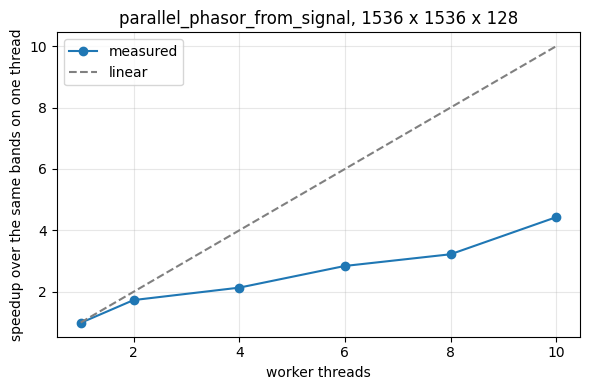

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
speedups = [
    scaling[n]["serial"] / scaling[n]["threaded"] for n in worker_counts
]
ax.plot(worker_counts, speedups, "o-", label="measured")
ax.plot(worker_counts, worker_counts, "--", color="grey", label="linear")
ax.set_xlabel("worker threads")
ax.set_ylabel("speedup over the same bands on one thread")
ax.set_title("parallel_phasor_from_signal, 1536 x 1536 x 128")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()

Threading keeps helping all the way to the core count, but at roughly
**40% of linear**. The array work is memory-bandwidth bound: the kernels are
cheap per byte, so beyond a handful of threads the cores spend their time
waiting on the same memory rather than computing. Extra threads past that
point buy little and cost peak memory, which is why `MAX_WORKERS` is capped at
16 however many cores are reported.

Note also that the baseline column improves as the band count rises — smaller
bands are more cache-friendly even on one thread. This measurement is
therefore a *conservative* estimate of the threading contribution, which is
the right direction for it to err in.

## 2. Median filtering

The single hottest interactive path in the plugin: median filtering dominates
what the filter tab does on a large image, and it re-runs on **every** slider
move.

Unlike the transform, the median filter is *not* point-wise — each pass reaches
`size // 2` pixels away. Each band is therefore grown by
`repeat * (size // 2)` rows on both sides and trimmed back afterwards, which
is what keeps the result bit-identical. That halo is redundant work, which is
why bands are only cut when each halo row earns at least `BAND_HALO_RATIO`
rows of real work.

In [7]:
print(f"BAND_HALO_RATIO = {BAND_HALO_RATIO}")

filter_rows = []
for shape in [(512, 512), (1024, 1024), (2048, 2048)]:
    mean, real, imag = make_phasor(shape)
    for repeat, size in ((1, 3), (3, 3), (1, 7)):
        result = timings(
            {
                "sequential": (
                    lambda m=mean, r=real, i=imag, rp=repeat, sz=size:
                    phasor_filter_median(m, r, i, repeat=rp, size=sz)
                ),
                "parallel": (
                    lambda m=mean, r=real, i=imag, rp=repeat, sz=size:
                    parallel_filter_median(
                        m, r, i, repeat=rp, size=sz, workers=CORES)
                ),
            },
            repeats=3,
        )
        filter_rows.append(
            (
                f"{shape[0]}x{shape[1]}",
                f"{shape[0] * shape[1] / 1e6:.1f}",
                repeat,
                size,
                f"{result['sequential'] * 1e3:.0f}",
                f"{result['parallel'] * 1e3:.0f}",
                f"{result['sequential'] / result['parallel']:.2f}x",
            )
        )
    del mean, real, imag

table(
    filter_rows,
    ["shape", "Mpx", "repeat", "size", "sequential ms", "parallel ms",
     "speedup"],
)

BAND_HALO_RATIO = 8


shape      Mpx  repeat  size  sequential ms  parallel ms  speedup
---------  ---  ------  ----  -------------  -----------  -------
512x512    0.3  1       3     63             62           1.01x  
512x512    0.3  3       3     152            152          1.00x  
512x512    0.3  1       7     386            386          1.00x  
1024x1024  1.0  1       3     249            52           4.76x  
1024x1024  1.0  3       3     612            135          4.52x  
1024x1024  1.0  1       7     1560           217          7.19x  
2048x2048  4.2  1       3     995            204          4.87x  
2048x2048  4.2  3       3     2442           514          4.75x  
2048x2048  4.2  1       7     6289           853          7.37x  


Two things to read out of that table.

**The 512 x 512 rows show no speedup at all — by design.** That image has
262,144 pixels, below the `MIN_PARALLEL_PIXELS` threshold of 1,048,576, so it
is filtered in one piece. Under roughly a megapixel the kernel finishes in a
few milliseconds and the thread hand-off plus the halo recomputation costs
more than it saves. The helper is a drop-in that decides for itself; it does
not need to be guarded at the call site.

**Bigger filters parallelise better.** A `size=7` filter does far more work
per row than `size=3`, so the fixed cost of the halo is amortised over more
useful work. The worst case for band splitting is a cheap filter on a
just-over-threshold image, which is exactly the case the threshold exists to
keep out.

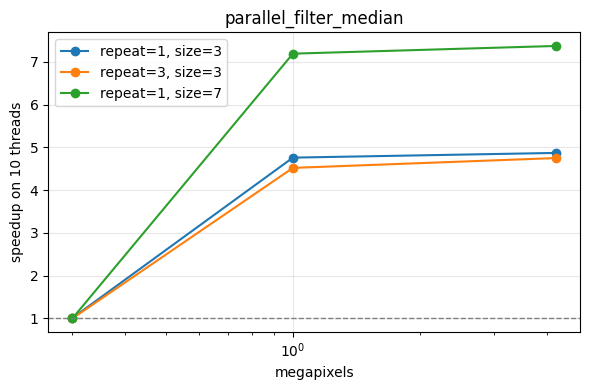

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
for repeat, size in ((1, 3), (3, 3), (1, 7)):
    xs, ys = [], []
    for row in filter_rows:
        if int(row[2]) == repeat and int(row[3]) == size:
            xs.append(float(row[1]))
            ys.append(float(row[6].rstrip("x")))
    ax.plot(xs, ys, "o-", label=f"repeat={repeat}, size={size}")
ax.axhline(1.0, color="grey", ls="--", lw=1)
ax.set_xscale("log")
ax.set_xlabel("megapixels")
ax.set_ylabel(f"speedup on {CORES} threads")
ax.set_title("parallel_filter_median")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()

## 3. Fanning out over items

The other half of the plugin's parallelism is per-*item* rather than
per-band: one worker per file when reading a stack, per layer when filtering
or analysing a selection, per file when exporting. `parallel_map` is the
helper underneath all of those.

Here, several independent images are median-filtered — the shape of
"filter every selected layer".

In [9]:
layers = [make_phasor((768, 768)) for _ in range(8)]


def filter_one(arrays):
    mean, real, imag = arrays
    return phasor_filter_median(mean, real, imag, repeat=1, size=5)


result = timings(
    {
        "sequential": lambda: [filter_one(a) for a in layers],
        f"parallel_map ({CORES})": lambda: parallel_map(
            filter_one, layers, workers=CORES
        ),
    },
    repeats=3,
)
print(f"{len(layers)} layers, 768x768, size=5 median")
print(f"  sequential   {result['sequential'] * 1e3:8.0f} ms")
print(f"  parallel_map {result[f'parallel_map ({CORES})'] * 1e3:8.0f} ms"
      f"   ({result['sequential'] / result[f'parallel_map ({CORES})']:.2f}x)")

8 layers, 768x768, size=5 median
  sequential       3607 ms
  parallel_map      638 ms   (5.66x)


Item fan-out scales better than band splitting: the items are genuinely
independent, there is no halo to recompute, and each worker's arrays are small
enough to stay local. This is why the plugin prefers to parallelise over items
where it can, and falls back to band splitting for the case that has only one
item — a single very large image.

**Pools never nest.** A reader that fans out over files calls helpers that
themselves fan out over bands. Letting both levels spawn `N` threads would
oversubscribe the machine badly, so `parallel_map` marks its worker threads
and any nested fan-out runs sequentially instead.

## 4. The results are identical

This is the guarantee that makes the switch a pure speed-versus-resources
choice rather than an accuracy one. Not "close" — the same values, the same
dtypes, the same NaN positions.

In [10]:
signal = make_signal((1024, 1024))
sequential = phasor_from_signal(signal, axis=0)
parallel = parallel_phasor_from_signal(signal, axis=0, workers=CORES)
for name, a, b in zip(
    ("mean", "real", "imag"), sequential, parallel, strict=True
):
    assert a.dtype == b.dtype, name
    assert np.array_equal(a, b, equal_nan=True), name
    print(f"phasor_from_signal   {name}: identical, dtype {a.dtype}")
del signal, sequential, parallel

mean, real, imag = make_phasor((1024, 1024))
mean[RNG.random(mean.shape) < 0.05] = np.nan  # NaNs must land in the same place
sequential = phasor_filter_median(mean, real, imag, repeat=3, size=5)
parallel = parallel_filter_median(
    mean, real, imag, repeat=3, size=5, workers=CORES
)
for name, a, b in zip(
    ("mean", "real", "imag"), sequential, parallel, strict=True
):
    assert a.dtype == b.dtype, name
    assert np.array_equal(a, b, equal_nan=True), name
    print(f"phasor_filter_median {name}: identical, dtype {a.dtype}, "
          f"{np.isnan(a).sum():,} NaN")
del mean, real, imag, sequential, parallel

phasor_from_signal   mean: identical, dtype float64
phasor_from_signal   real: identical, dtype float64
phasor_from_signal   imag: identical, dtype float64


phasor_filter_median mean: identical, dtype float64, 52,505 NaN
phasor_filter_median real: identical, dtype float64, 0 NaN
phasor_filter_median imag: identical, dtype float64, 0 NaN


The plugin's own test suite asserts this across a matrix of shapes, harmonic
counts, dtypes and filter parameters, with the band-splitting threshold
patched down to one pixel so that even tiny test arrays exercise the split
path.

The one setting that is **not** bit-identical is **Phasor precision**, and
that is exactly why it is a separate, opt-in control rather than something
folded into the others.

## 5. Memory, not just time

Parallelism changes the memory profile as well as the schedule: a sequential
file read holds one decoded signal, a pool of `N` holds `N`. The
**Memory budget** setting is the share of currently free RAM that concurrent
work may occupy, and it is what sizes every pool whose items are large enough
to matter.

In [11]:
from napari_phasors._parallel import available_memory, memory_fraction

free = available_memory()
print(f"free memory      {free / 2**30:.1f} GB")
print(f"memory fraction  {memory_fraction():.0%}")
print(f"budget           {free * memory_fraction() / 2**30:.1f} GB\n")

table(
    [
        (
            f"{item_mb} MB",
            items_for_memory(item_mb * 2**20),
            workers_for_memory(item_mb * 2**20, n_items=32),
        )
        for item_mb in (16, 64, 256, 1024, 4096)
    ],
    ["item size", "items in budget", "workers for 32 items"],
)

free memory      7.8 GB
memory fraction  50%
budget           3.9 GB

item size  items in budget  workers for 32 items
---------  ---------------  --------------------
16 MB      249              10                  
64 MB      62               10                  
256 MB     15               10                  
1024 MB    3                3                   
4096 MB    1                1                   


Lower the budget when a large stack runs the machine out of memory; raise it
on a machine with headroom and nothing else running. It is the one knob that
makes the whole plugin less memory-hungry, because every pool sized against
whole images reads it.

## Reproducing this

Run this notebook. Nothing here reads a data file, so the only thing that
changes between machines is the hardware.

To compare against a genuinely sequential run — the same thing the
**Parallel processing** switch does — set the environment variable before
starting napari or Jupyter:

```bash
NAPARI_PHASORS_WORKERS=1 napari
```

That takes precedence over any worker count a call site asks for, which makes
it the reliable way to get a single-threaded reference for a timing
comparison.

## Summary

| Question | Answer measured here |
|---|---|
| Phasor transform speedup | About 2.5x from band splitting alone, about 4x again from threads on 10 cores — roughly 10x combined. |
| Median filter speedup | Roughly 5x above the threshold, rising to nearly 8x for larger filters; nothing at all below `MIN_PARALLEL_PIXELS`, by design. |
| Per-layer fan-out | About 6x on 8 layers — better than band splitting, since the items are independent and there is no halo. |
| Correctness | Bit-identical: same values, same dtypes, same NaN positions. |
| Memory | Grows with the pool; bounded by the **Memory budget** setting. |